# Telehealth — EDA e Classificação (padrão 1ESPA)

**Objetivo didático:** organizar a análise no estilo do professor, com EDA padronizada e um problema de classificação binária (alta adoção = top 25% por trimestre), usando **Regressão Logística (L1/L2)** e **SVM RBF**, validação simples e métricas clássicas. Extras ficam no **Apêndice**.

## 1. Definições e Preparos

- **Alvo (classe binária):** `y=1` se `% Telehealth` do estado estiver no **quartil superior (Q3)** do próprio **trimestre (Year × quarter)**; caso contrário `y=0`.
- **Recorte para modelagem:** Estado × Trimestre, com as demais dimensões em `All`.
- **Features (X):**
  - `Year` e `quarter` (numéricos simples);
  - `elig_rate` = `Total_Bene_TH_Elig / Total_PartB_Enrl` (taxa de elegibilidade);
  - `pct_lag1` = defasagem de 1 trimestre de `% Telehealth` por estado.
- **Partição temporal:** Treino (2020–2023), Validação (2024), Teste (2025-Q1).
- **Modelos:** `LogisticRegression` (penalidades **L1** e **L2**) e `SVC(kernel='rbf')`.
- **Seleção:** `GridSearchCV` enxuto (pequeno) por **AUC-ROC**; limiar escolhido por **F1** na validação.

In [7]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

# Modelagem
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             classification_report, confusion_matrix,
                             roc_curve, precision_recall_curve,
                             precision_score, recall_score, precision_recall_fscore_support)

# Reprodutibilidade básica
np.random.seed(42)

In [8]:
def to_percent(x, pos):
    return f"{x*100:.0f}%"

def ceil_to_step(value, step=0.05):
    if value <= 0:
        return step
    k = int(np.ceil(value / step))
    return k * step

FIGDIR = Path("./Graficos/")
FIGDIR.mkdir(exist_ok=True, parents=True)
print("Figuras serão salvas em:", FIGDIR)

Figuras serão salvas em: Graficos


In [9]:
CSV_PATH = Path("./Medicare_Telehealth_Trends_Q1_2025.csv")
df = pd.read_csv(CSV_PATH)

# Tipos e colunas principais
df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")
df["quarter"] = pd.to_numeric(df["quarter"].astype(str).str.replace("Q","", regex=False), errors="coerce").astype("Int64")
df["Pct_Telehealth"] = pd.to_numeric(df["Pct_Telehealth"], errors="coerce")
df = df.dropna(subset=["Year","quarter","Pct_Telehealth"]).copy()

# Último período nacional
last_year = int(df.loc[df["Bene_Geo_Desc"]=="National","Year"].max())
last_q = int(df[(df["Bene_Geo_Desc"]=="National") & (df["Year"]==last_year)]["quarter"].max())

print("Último período:", last_year, f"Q{last_q}")
df.head(3)

Último período: 2025 Q1


,Year,quarter,Bene_Geo_Desc,Bene_Mdcd_Mdcr_Enrl_Stus,Bene_Race_Desc,Bene_Sex_Desc,Bene_Mdcr_Entlmt_Stus,Bene_Age_Desc,Bene_RUCA_Desc,Total_Bene_TH_Elig,Total_PartB_Enrl,Total_Bene_Telehealth,Pct_Telehealth
1204,2020,1,National,All,All,All,All,All,All,23992421.0,3.218224e+07,1665085.0,0.0694
1205,2020,1,National,Medicare & Medicaid,All,All,All,All,All,4977118.0,6.292755e+06,493310.0,0.0991
1206,2020,1,National,Medicare Only,All,All,All,All,All,19015303.0,2.588948e+07,1171775.0,0.0616


## 2. EDA — Séries temporais (Nacional e RUCA)

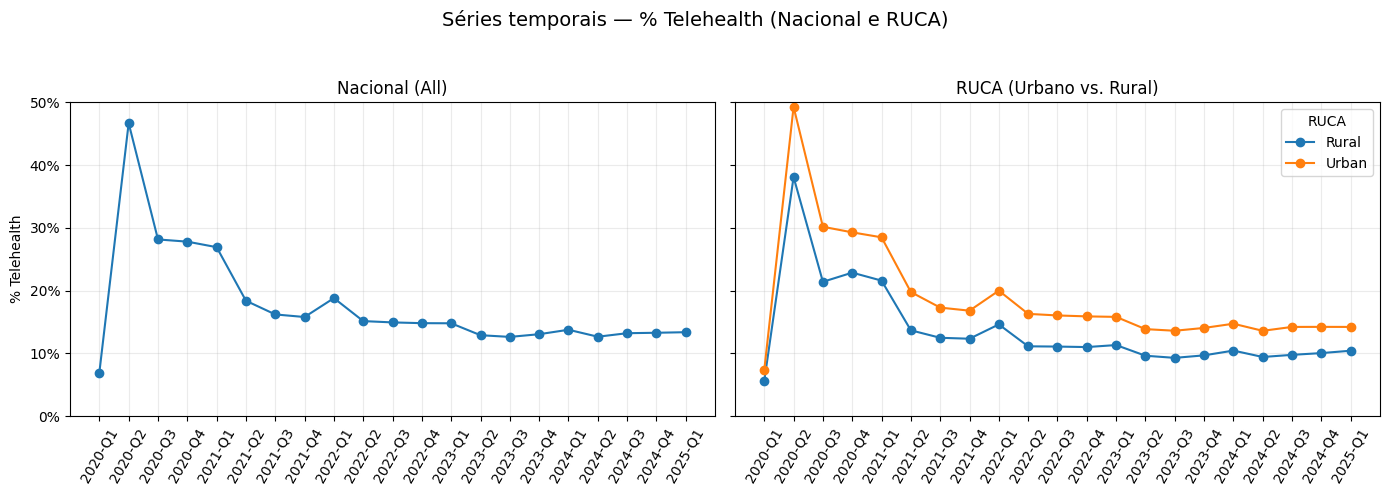

<Figure size 640x480 with 0 Axes>

In [23]:
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25})

# Nacional (All)
nat = df[(df["Bene_Geo_Desc"]=="National") &
         (df["Bene_RUCA_Desc"]=="All") &
         (df["Bene_Mdcd_Mdcr_Enrl_Stus"]=="All") &
         (df["Bene_Mdcr_Entlmt_Stus"]=="All") &
         (df["Bene_Race_Desc"]=="All") &
         (df["Bene_Sex_Desc"]=="All") &
         (df["Bene_Age_Desc"]=="All")].copy()

# RUCA (Nacional, Urban/Rural)
ruca = df[(df["Bene_Geo_Desc"]=="National") &
          (df["Bene_Mdcd_Mdcr_Enrl_Stus"]=="All") &
          (df["Bene_Mdcr_Entlmt_Stus"]=="All") &
          (df["Bene_Race_Desc"]=="All") &
          (df["Bene_Sex_Desc"]=="All") &
          (df["Bene_Age_Desc"]=="All") &
          (df["Bene_RUCA_Desc"].isin(["All","Urban","Rural"]))].copy()

# Série temporal = ordenar por Year, quarter
nat = nat.sort_values(["Year","quarter"])
ruca = ruca.sort_values(["Year","quarter","Bene_RUCA_Desc"])

# Limite Y comum
ymax = ceil_to_step(max(nat["Pct_Telehealth"].max(), ruca["Pct_Telehealth"].max()), step=0.05)

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)
fig.suptitle("Séries temporais — % Telehealth (Nacional e RUCA)", fontsize=14)

# Nacional
axes[0].plot(nat["Year"].astype(str)+"-Q"+nat["quarter"].astype(str), nat["Pct_Telehealth"], marker="o")
axes[0].set_title("Nacional (All)"); axes[0].set_ylabel("% Telehealth"); axes[0].set_ylim(0, ymax)
axes[0].tick_params(axis='x', rotation=60)
axes[0].yaxis.set_major_formatter(FuncFormatter(to_percent))

# RUCA
for label, grp in ruca.groupby("Bene_RUCA_Desc"):
    if label=="All": 
        continue
    x = grp["Year"].astype(str)+"-Q"+grp["quarter"].astype(str)
    axes[1].plot(x, grp["Pct_Telehealth"], marker="o", label=label)
axes[1].set_title("RUCA (Urbano vs. Rural)"); axes[1].set_ylim(0, ymax)
axes[1].tick_params(axis='x', rotation=60)
axes[1].yaxis.set_major_formatter(FuncFormatter(to_percent))
axes[1].legend(title="RUCA")

plt.tight_layout(rect=[0,0,1,0.94]); plt.show()
plt.savefig(FIGDIR/"01_temporal.png", dpi=200)

## 3. EDA — Distribuições e RUCA

C:\Users\Gustavo\AppData\Local\Temp\ipykernel_7184\3712388984.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(box_data, labels=labels, vert=True)


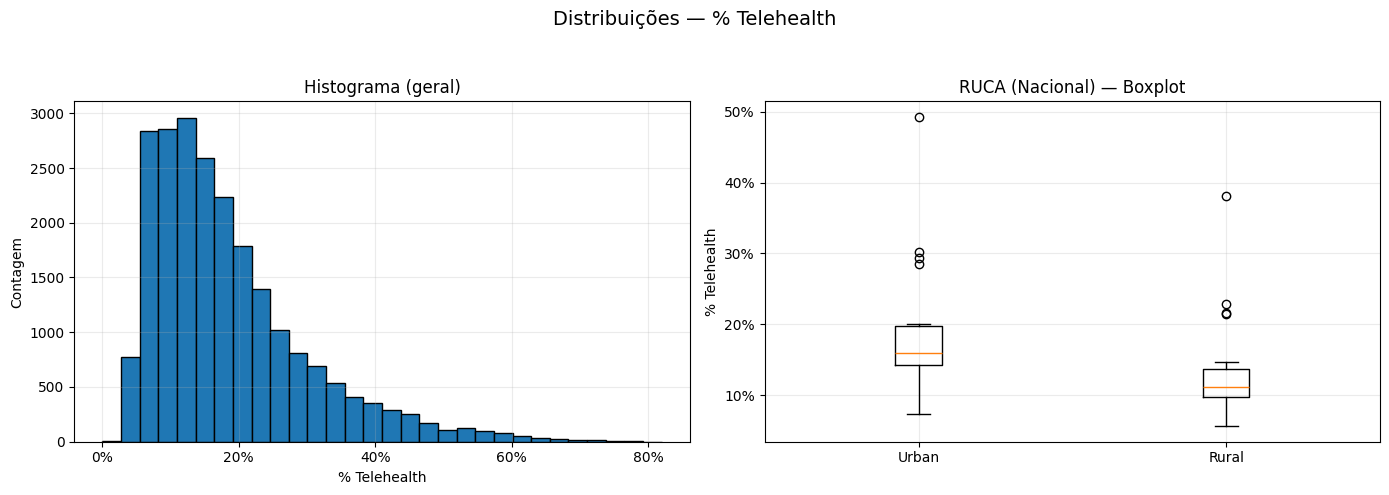

<Figure size 640x480 with 0 Axes>

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=False)
fig.suptitle("Distribuições — % Telehealth", fontsize=14)

# Histograma (All, estados + nacional)
axes[0].hist(df["Pct_Telehealth"].dropna().values, bins=30, edgecolor="black")
axes[0].set_title("Histograma (geral)"); axes[0].set_xlabel("% Telehealth"); axes[0].set_ylabel("Contagem")
axes[0].xaxis.set_major_formatter(FuncFormatter(to_percent))

# Boxplot RUCA (National)
box_data = []
labels = []
for lab in ["Urban","Rural"]:
    m = (df["Bene_Geo_Desc"]=="National") & \
        (df["Bene_RUCA_Desc"]==lab) & \
        (df["Bene_Mdcd_Mdcr_Enrl_Stus"]=="All") & (df["Bene_Mdcr_Entlmt_Stus"]=="All") & \
        (df["Bene_Race_Desc"]=="All") & (df["Bene_Sex_Desc"]=="All") & (df["Bene_Age_Desc"]=="All")
    v = df.loc[m, "Pct_Telehealth"].dropna().values
    if len(v)>0:
        box_data.append(v); labels.append(lab)
axes[1].boxplot(box_data, labels=labels, vert=True)
axes[1].set_title("RUCA (Nacional) — Boxplot"); axes[1].set_ylabel("% Telehealth")
axes[1].yaxis.set_major_formatter(FuncFormatter(to_percent))

plt.tight_layout(rect=[0,0,1,0.94]); plt.show()
plt.savefig(FIGDIR/"02_distribuicoes.png")

## 4. EDA — Demografia (Nacional, All em outras dimensões)

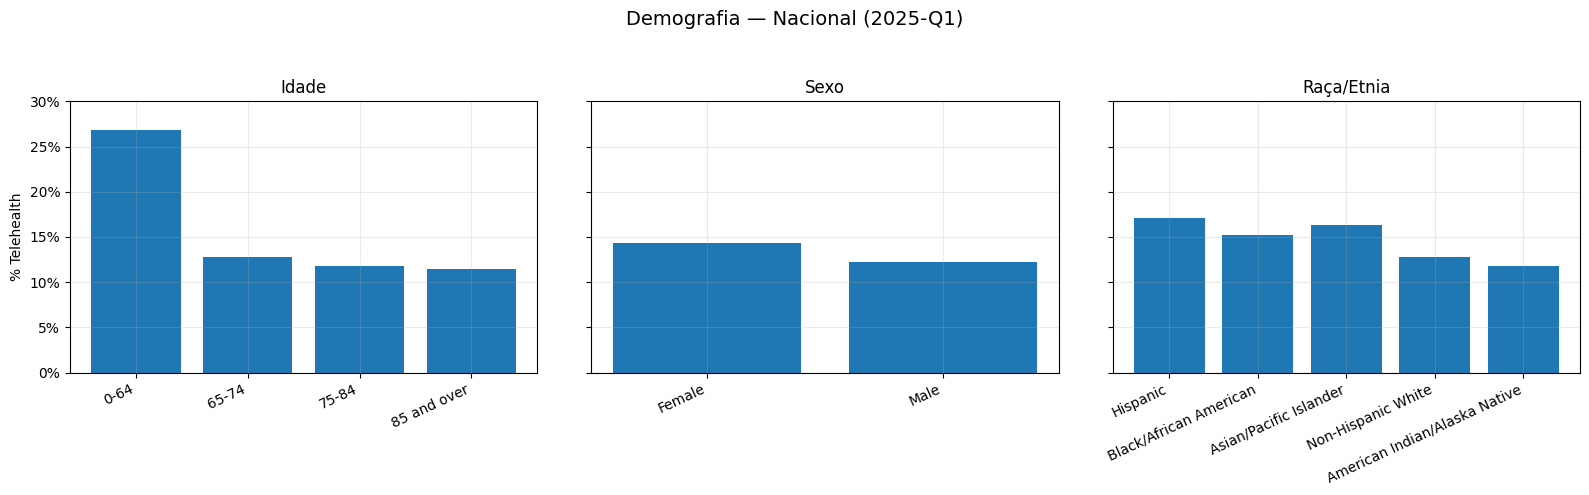

In [27]:
# --- Painel Demografia (robusto e padronizado) ---

FIGDIR.mkdir(parents=True, exist_ok=True)

def get_series(col, labels):
    # base "All" para todas as demais dimensões demográficas
    m = (
        (df['Bene_Geo_Desc'] == 'National') &
        (df['Bene_RUCA_Desc'] == 'All') &
        (df['Bene_Mdcd_Mdcr_Enrl_Stus'] == 'All') &
        (df['Bene_Mdcr_Entlmt_Stus'] == 'All') &
        (df['Year'] == last_year) & (df['quarter'] == last_q)
    )
    for other in ['Bene_Age_Desc', 'Bene_Sex_Desc', 'Bene_Race_Desc']:
        if other != col:
            m &= (df[other] == 'All')

    tmp = df.loc[m, [col, 'Pct_Telehealth']].dropna(subset=[col])
    # reindex garante ordem dos rótulos e insere NaN quando faltar dado
    s = (tmp.set_index(col)['Pct_Telehealth']
            .reindex(labels))
    return s.to_numpy(dtype=float)

ages  = ['0-64', '65-74', '75-84', '85 and over']
sexs  = ['Female', 'Male']
races = ['Hispanic', 'Black/African American', 'Asian/Pacific Islander',
         'Non-Hispanic White', 'American Indian/Alaska Native']  # ajuste aos rótulos do seu CSV

v_age = get_series('Bene_Age_Desc',  ages)
v_sex = get_series('Bene_Sex_Desc',  sexs)
v_rac = get_series('Bene_Race_Desc', races)

# Escala unificada da família (com tolerância a NaN)
ymax = ceil_to_step(np.nanmax([np.nanmax(v_age), np.nanmax(v_sex), np.nanmax(v_rac)]), step=0.05)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle(f'Demografia — Nacional ({last_year}-Q{last_q})', fontsize=14)

axes[0].bar(ages, v_age)
axes[0].set_title('Idade')
axes[0].set_ylim(0, ymax)
axes[0].set_ylabel('% Telehealth')

axes[1].bar(sexs, v_sex)
axes[1].set_title('Sexo')
axes[1].set_ylim(0, ymax)

axes[2].bar(races, v_rac)
axes[2].set_title('Raça/Etnia')
axes[2].set_ylim(0, ymax)

for ax in axes:
    ax.yaxis.set_major_formatter(FuncFormatter(to_percent))
    ax.tick_params(axis='x', rotation=25)
    for tick in ax.get_xticklabels():
        tick.set_ha('right')

plt.tight_layout(rect=[0, 0, 1, 0.94])
# salve ANTES do show
plt.savefig(FIGDIR / '03_demografia.png', dpi=200)
plt.show()


## 5. EDA — Status (Nacional)

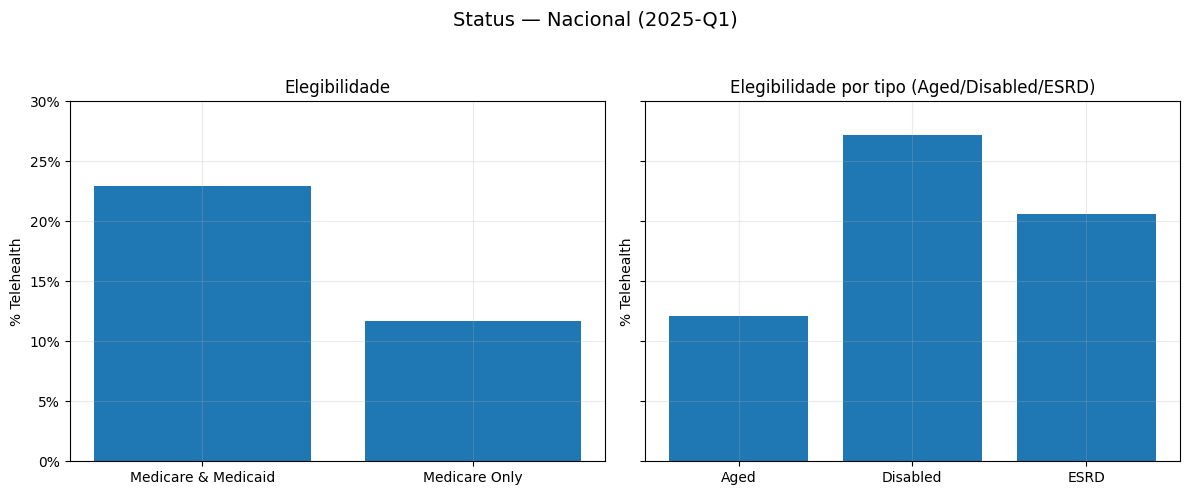

<Figure size 640x480 with 0 Axes>

In [26]:
# Dual vs Only
def get_pct_national(**conds):
    m = (df["Bene_Geo_Desc"]=="National") & (df["Year"]==last_year) & (df["quarter"]==last_q)
    for k,v in conds.items():
        m &= (df[k]==v)
    s = df.loc[m,"Pct_Telehealth"]
    return float(s.iloc[0]) if len(s)>0 else np.nan

dual = get_pct_national(Bene_RUCA_Desc="All", Bene_Mdcd_Mdcr_Enrl_Stus="Medicare & Medicaid",
                        Bene_Mdcr_Entlmt_Stus="All", Bene_Race_Desc="All", Bene_Sex_Desc="All", Bene_Age_Desc="All")
only = get_pct_national(Bene_RUCA_Desc="All", Bene_Mdcd_Mdcr_Enrl_Stus="Medicare Only",
                        Bene_Mdcr_Entlmt_Stus="All", Bene_Race_Desc="All", Bene_Sex_Desc="All", Bene_Age_Desc="All")

# Entitlement
labels_ent = ["Aged","Disabled","ESRD"]
vals_ent = [get_pct_national(Bene_RUCA_Desc="All", Bene_Mdcr_Entlmt_Stus=lab,
                             Bene_Mdcd_Mdcr_Enrl_Stus="All", Bene_Race_Desc="All", Bene_Sex_Desc="All", Bene_Age_Desc="All")
            for lab in labels_ent]

ymax = ceil_to_step(np.nanmax([dual, only, np.nanmax(vals_ent)]), step=0.05)

fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)
fig.suptitle(f"Status — Nacional ({last_year}-Q{last_q})", fontsize=14)

axes[0].bar(["Medicare & Medicaid","Medicare Only"], [dual, only])
axes[0].set_title("Elegibilidade"); axes[0].set_ylim(0, ymax)

axes[1].bar(labels_ent, vals_ent)
axes[1].set_title("Elegibilidade por tipo (Aged/Disabled/ESRD)"); axes[1].set_ylim(0, ymax)

for ax in axes:
    ax.set_ylabel("% Telehealth"); ax.yaxis.set_major_formatter(FuncFormatter(to_percent))

plt.tight_layout(rect=[0,0,1,0.94]); plt.show()
plt.savefig(FIGDIR/"04_status.png", dpi=200)

## 6. EDA — Rankings estaduais (Top/Bottom) — gráfico único

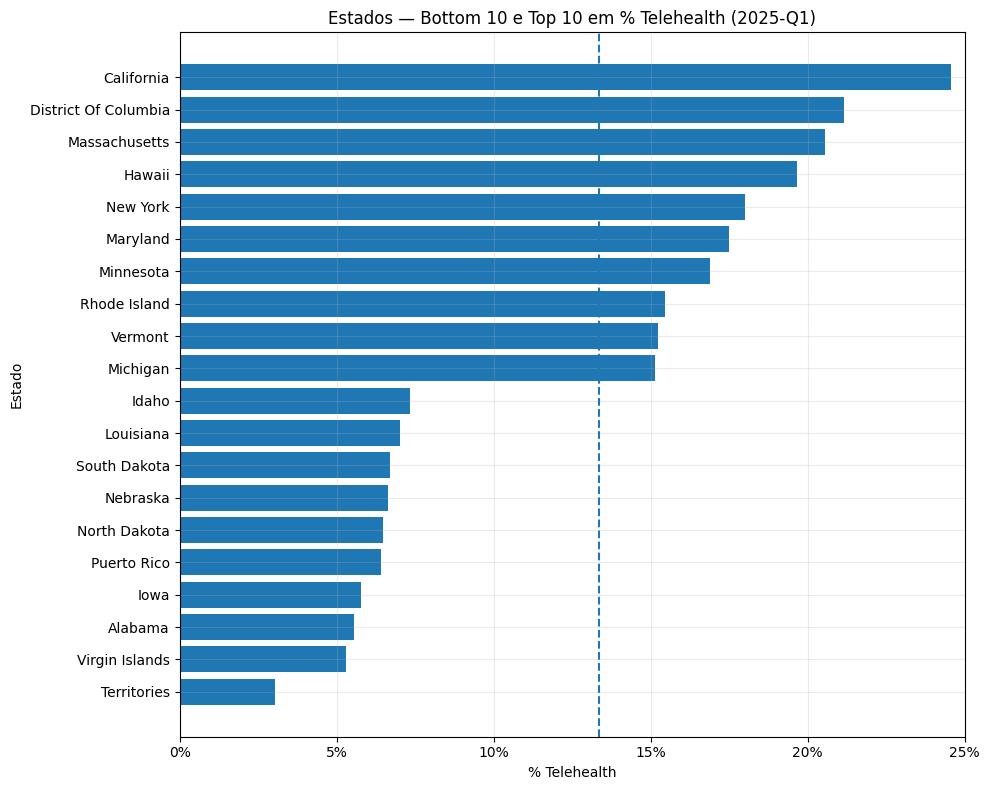

<Figure size 640x480 with 0 Axes>

In [14]:
state_latest = df[(df["Bene_Geo_Desc"]!="National") &
                  (df["Year"]==last_year) & (df["quarter"]==last_q) &
                  (df["Bene_RUCA_Desc"]=="All") & (df["Bene_Mdcd_Mdcr_Enrl_Stus"]=="All") &
                  (df["Bene_Mdcr_Entlmt_Stus"]=="All") & (df["Bene_Race_Desc"]=="All") &
                  (df["Bene_Sex_Desc"]=="All") & (df["Bene_Age_Desc"]=="All")][["Bene_Geo_Desc","Pct_Telehealth"]].copy()

top10 = state_latest.nlargest(10, "Pct_Telehealth").copy(); top10["Grupo"]="Top 10"
bot10 = state_latest.nsmallest(10, "Pct_Telehealth").copy(); bot10["Grupo"]="Bottom 10"

combo = pd.concat([bot10, top10], ignore_index=True).sort_values("Pct_Telehealth", ascending=True)

fig, ax = plt.subplots(1,1, figsize=(10,8))
bars = ax.barh(combo["Bene_Geo_Desc"], combo["Pct_Telehealth"])
ax.set_title(f"Estados — Bottom 10 e Top 10 em % Telehealth ({last_year}-Q{last_q})")
ax.set_xlabel("% Telehealth"); ax.set_ylabel("Estado")

xlim = ceil_to_step(float(combo["Pct_Telehealth"].max()), step=0.05)
ax.set_xlim(0, xlim)
ax.xaxis.set_major_formatter(FuncFormatter(to_percent))

# linha da média nacional
nat = get_pct_national(Bene_RUCA_Desc="All", Bene_Mdcd_Mdcr_Enrl_Stus="All",
                       Bene_Mdcr_Entlmt_Stus="All", Bene_Race_Desc="All", Bene_Sex_Desc="All", Bene_Age_Desc="All")
ax.axvline(nat, linestyle="--")

plt.tight_layout(); plt.show()
plt.savefig(FIGDIR/"05_rankings_estados.png", dpi=200)

## 7. EDA — Correlações (numéricas)

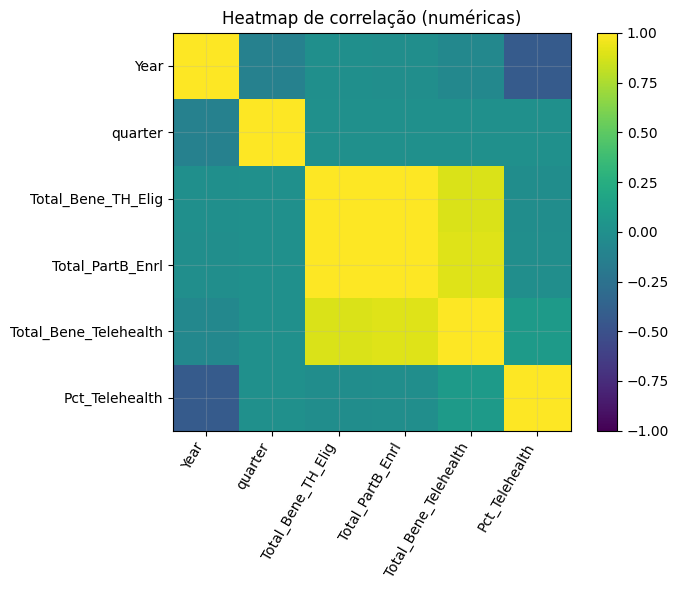

<Figure size 640x480 with 0 Axes>

In [15]:
num_cols = [c for c in df.columns if df[c].dtype.kind in "if"]
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(corr.values, vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=60, ha="right")
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Heatmap de correlação (numéricas)")
plt.tight_layout(); plt.show()
plt.savefig(FIGDIR/"06_correlacao.png", dpi=200)

## 8. Classe binária (top 25% por trimestre), features e split

In [16]:
# Base estado × trimestre com demais dimensões em 'All'
base = df[(df["Bene_Geo_Desc"]!="National") &
          (df["Bene_RUCA_Desc"]=="All") &
          (df["Bene_Mdcd_Mdcr_Enrl_Stus"]=="All") &
          (df["Bene_Mdcr_Entlmt_Stus"]=="All") &
          (df["Bene_Race_Desc"]=="All") &
          (df["Bene_Sex_Desc"]=="All") &
          (df["Bene_Age_Desc"]=="All")].copy()

def label_top25(grp):
    q75 = grp["Pct_Telehealth"].quantile(0.75)
    return (grp["Pct_Telehealth"]>=q75).astype(int)

base["y"] = base.groupby(["Year","quarter"], group_keys=False).apply(label_top25)

# features
base["elig_rate"] = base["Total_Bene_TH_Elig"] / base["Total_PartB_Enrl"]
base = base.sort_values(["Bene_Geo_Desc","Year","quarter"])
base["pct_lag1"] = base.groupby("Bene_Geo_Desc")["Pct_Telehealth"].shift(1)
base = base.dropna(subset=["elig_rate","pct_lag1"]).reset_index(drop=True)

# Split temporal
train = base[(base["Year"]>=2020) & (base["Year"]<=2023)]
valid = base[(base["Year"]==2024)]
test  = base[(base["Year"]==2025) & (base["quarter"]==1)]

features = ["Year","quarter","elig_rate","pct_lag1"]
X_train, y_train = train[features], train["y"]
X_valid, y_valid = valid[features], valid["y"]
X_test,  y_test  = test[features],  test["y"]

X_train.shape, X_valid.shape, X_test.shape

C:\Users\Gustavo\AppData\Local\Temp\ipykernel_7184\1477475559.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  base["y"] = base.groupby(["Year","quarter"], group_keys=False).apply(label_top25)


((810, 4), (216, 4), (54, 4))

## 9. Modelagem — Logística (L1/L2) e SVM-RBF (grid curto)

In [17]:
# Logística
logit = Pipeline([('scaler', StandardScaler()),
                  ('clf', LogisticRegression(solver='liblinear', class_weight='balanced', max_iter=200))])
param_logit = {'clf__penalty':['l1','l2'], 'clf__C':[0.01,0.1,1,10,100]}
gs_logit = GridSearchCV(logit, param_logit, cv=5, scoring='roc_auc', n_jobs=-1)
gs_logit.fit(X_train, y_train)
best_logit = gs_logit.best_estimator_
print("Melhor Logística:", gs_logit.best_params_, "| AUC(cv)=", round(gs_logit.best_score_,4))

# SVM RBF
svm = Pipeline([('scaler', StandardScaler()),
                ('clf', SVC(kernel='rbf', probability=True, class_weight='balanced'))])
param_svm = {'clf__C':[0.1,1,10], 'clf__gamma':['scale', 0.1, 0.01]}
gs_svm = GridSearchCV(svm, param_svm, cv=5, scoring='roc_auc', n_jobs=-1)
gs_svm.fit(X_train, y_train)
best_svm = gs_svm.best_estimator_
print("Melhor SVM:", gs_svm.best_params_, "| AUC(cv)=", round(gs_svm.best_score_,4))

Melhor Logística: {'clf__C': 10, 'clf__penalty': 'l2'} | AUC(cv)= 0.8445
Melhor SVM: {'clf__C': 10, 'clf__gamma': 'scale'} | AUC(cv)= 0.9688


## 10. Seleção de limiar por F1 (validação) e escolha do modelo

In [18]:
def evaluate(model, X, y, name='model', thr=None):
    proba = model.predict_proba(X)[:,1]
    auc = roc_auc_score(y, proba)
    ap  = average_precision_score(y, proba)
    if thr is None:
        thr_grid = np.linspace(0.1, 0.9, 17)
        f1s = [f1_score(y, (proba>=t).astype(int)) for t in thr_grid]
        thr = float(thr_grid[int(np.argmax(f1s))])
    yhat = (proba >= thr).astype(int)
    f1v = f1_score(y, yhat)
    return {'model': name, 'AUC': auc, 'AP': ap, 'F1': f1v, 'thr': thr, 'proba': proba, 'yhat': yhat}

res_logit = evaluate(best_logit, X_valid, y_valid, name='Logit')
res_svm   = evaluate(best_svm,   X_valid, y_valid, name='SVM-RBF')
print(res_logit); print(res_svm)

winner = res_logit if res_logit['AUC'] >= res_svm['AUC'] else res_svm
chosen_model = best_logit if winner['model']=='Logit' else best_svm
chosen_thr = winner['thr']
print("Modelo escolhido:", winner['model'], "| thr =", round(chosen_thr,3))

{'model': 'Logit', 'AUC': 0.9770089285714286, 'AP': 0.9409920784751855, 'F1': 0.835820895522388, 'thr': 0.65, 'proba': array([0.36759622, 0.40639383, 0.40520967, 0.4459547 , 0.65097446,
       0.69462733, 0.67539754, 0.73102591, 0.63511404, 0.67422495,
       0.68861933, 0.72394202, 0.47263741, 0.51624772, 0.49909387,
       0.53633023, 0.89874426, 0.91678709, 0.91779674, 0.93280243,
       0.62343322, 0.66486536, 0.64302947, 0.68889109, 0.67892874,
       0.7206201 , 0.69292569, 0.74131975, 0.66385962, 0.70971587,
       0.6815624 , 0.72011655, 0.83742127, 0.86568474, 0.85601806,
       0.88047616, 0.58555496, 0.62700764, 0.64536068, 0.7054099 ,
       0.50160596, 0.53350818, 0.53557348, 0.58702417, 0.80906037,
       0.8471253 , 0.87379363, 0.88103634, 0.37930679, 0.43338006,
       0.43759451, 0.47383688, 0.55429963, 0.60709446, 0.58259147,
       0.62283849, 0.42848029, 0.46637538, 0.46163023, 0.49394701,
       0.36289519, 0.41393757, 0.39442705, 0.42563785, 0.40550823,
       0.4

## 11. Resultados no teste (2025-Q1)

In [19]:
proba_tst = chosen_model.predict_proba(X_test)[:,1]
yhat_test = (proba_tst >= chosen_thr).astype(int)

print("Teste — ROC-AUC:", round(roc_auc_score(y_test, proba_tst), 4))
print("Teste — AP:", round(average_precision_score(y_test, proba_tst), 4))
print(classification_report(y_test, yhat_test, digits=3))

cm = confusion_matrix(y_test, yhat_test, labels=[0,1])
cm

Teste — ROC-AUC: 0.9857
Teste — AP: 0.9644
              precision    recall  f1-score   support

           0      1.000     0.550     0.710        40
           1      0.438     1.000     0.609        14

    accuracy                          0.667        54
   macro avg      0.719     0.775     0.659        54
weighted avg      0.854     0.667     0.683        54



array([[22, 18],
       [ 0, 14]])

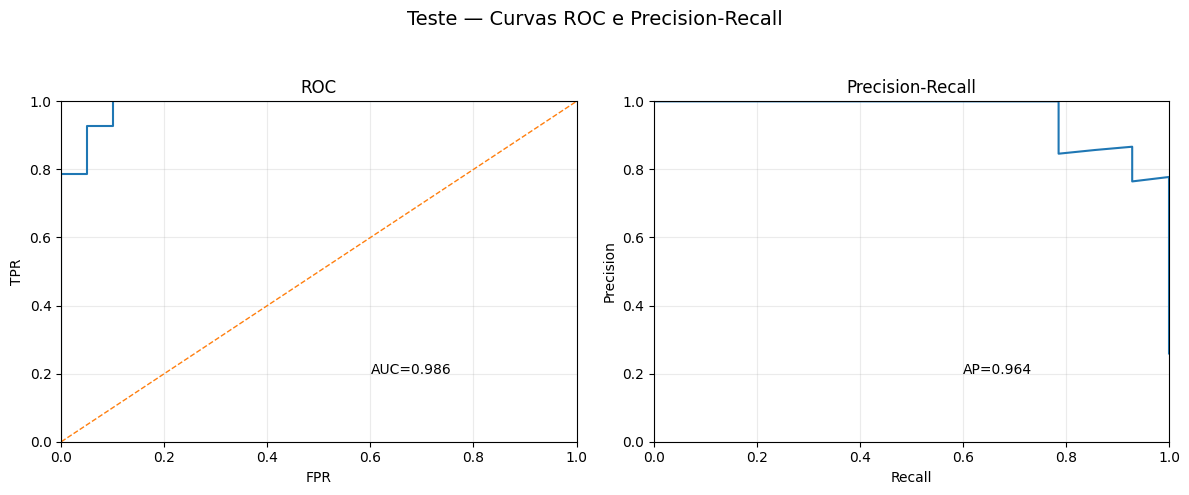

<Figure size 640x480 with 0 Axes>

In [20]:
# Curvas ROC e PR em subplots (mesma escala)
fpr, tpr, _ = roc_curve(y_test, proba_tst)
prec, rec, _ = precision_recall_curve(y_test, proba_tst)

fig, axes = plt.subplots(1,2, figsize=(12,5))
fig.suptitle("Teste — Curvas ROC e Precision-Recall", fontsize=14)

axes[0].plot(fpr, tpr); axes[0].plot([0,1],[0,1],'--',lw=1)
axes[0].set_title("ROC"); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_xlim(0,1); axes[0].set_ylim(0,1)
axes[0].text(0.6,0.2,f"AUC={roc_auc_score(y_test, proba_tst):.3f}")

axes[1].plot(rec, prec)
axes[1].set_title("Precision-Recall"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_xlim(0,1); axes[1].set_ylim(0,1)
axes[1].text(0.6,0.2,f"AP={average_precision_score(y_test, proba_tst):.3f}")

plt.tight_layout(rect=[0,0,1,0.94]); plt.show()
plt.savefig(FIGDIR/"07_roc_pr_teste.png", dpi=200)

## 12. Tabela final de métricas (validação vs. teste)

In [21]:
def metrics_table(model, thr, Xv, yv, Xt, yt):
    pv = model.predict_proba(Xv)[:,1]; yhv = (pv>=thr).astype(int)
    pt = model.predict_proba(Xt)[:,1]; yht = (pt>=thr).astype(int)
    def pack(y, p, yh):
        P, R, F, _ = precision_recall_fscore_support(y, yh, average='binary', zero_division=0)
        return {
            'AUC': round(roc_auc_score(y, p),3),
            'AP' : round(average_precision_score(y, p),3),
            'F1' : round(F,3),
            'Precision': round(P,3),
            'Recall':    round(R,3)
        }
    return pd.DataFrame([{'partição':'validação', **pack(yv,pv,yhv)},
                         {'partição':'teste',      **pack(yt,pt,yht)}])

mt = metrics_table(chosen_model, chosen_thr, X_valid, y_valid, X_test, y_test)
display(mt)
mt.to_csv(FIGDIR/"metricas_finais.csv", index=False)
print("Salvo:", FIGDIR/"metricas_finais.csv")

,partição,AUC,AP,F1,Precision,Recall
0,validação,0.977,0.941,0.836,0.718,1.0
1,teste,0.986,0.964,0.609,0.438,1.0


Salvo: Graficos\metricas_finais.csv


## 13. Conclusões (curtas)

- A EDA evidencia pico de telehealth em 2020 e estabilização posterior; **Urbano > Rural** e **Dual/Disabled** acima dos demais grupos.
- O rótulo binário **top 25% por trimestre** foi previsto com modelos no escopo da disciplina (Logística L1/L2 e SVM RBF) com **grid curto**.
- Selecionamos o limiar por **F1** na validação; no teste, reportamos **ROC-AUC**, **AP**, **F1**, **precision**, **recall** e **matriz de confusão**.
- As figuras foram padronizadas (subplots comparáveis, eixos com mesma escala, percentuais formatados) e salvas para o PDF.

## Apêndice (opcional) — Calibração e Lift (fora do escopo principal)

> Esta seção é opcional e **não** é cobrada pelo professor. Inclui curva de calibração e lift cumulativo, apenas como apoio.

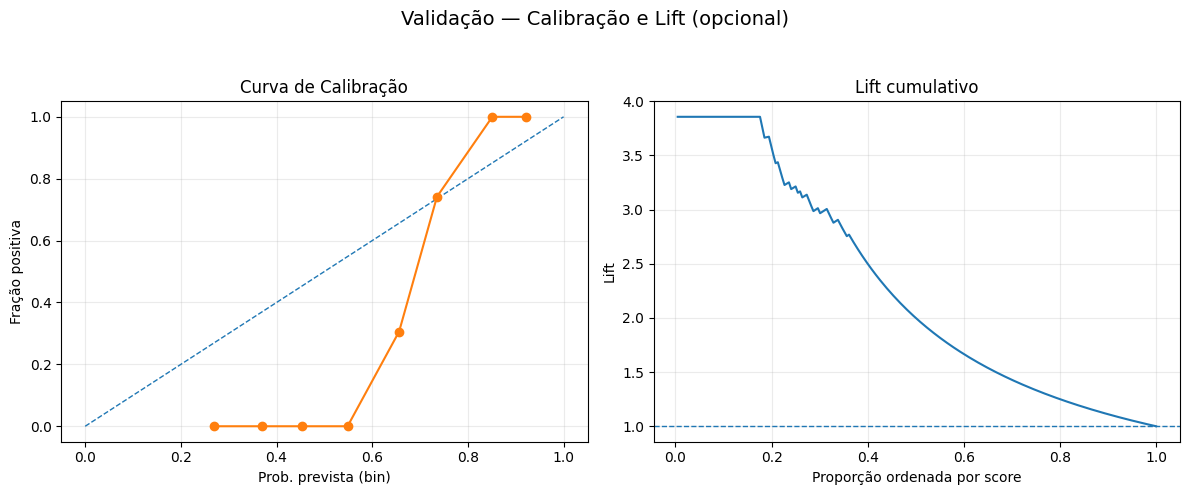

<Figure size 640x480 with 0 Axes>

In [22]:
# Curva de calibração e lift (opcional)
from sklearn.calibration import calibration_curve

proba_val = chosen_model.predict_proba(X_valid)[:,1]

frac_pos, mean_pred = calibration_curve(y_valid, proba_val, n_bins=10, strategy='uniform')

fig, axes = plt.subplots(1,2, figsize=(12,5))
fig.suptitle("Validação — Calibração e Lift (opcional)", fontsize=14)

# Calibração
axes[0].plot([0,1],[0,1],'--',lw=1)
axes[0].plot(mean_pred, frac_pos, marker='o')
axes[0].set_title("Curva de Calibração"); axes[0].set_xlabel("Prob. prevista (bin)"); axes[0].set_ylabel("Fração positiva")

# Lift cumulativo
order = np.argsort(proba_val)[::-1]
y_sorted = y_valid.values[order]
cum_pos = np.cumsum(y_sorted)
perc = np.arange(1, len(y_sorted)+1) / len(y_sorted)
lift = (cum_pos / cum_pos[-1]) / perc

axes[1].plot(perc, lift); axes[1].axhline(1.0, ls='--', lw=1)
axes[1].set_title("Lift cumulativo"); axes[1].set_xlabel("Proporção ordenada por score"); axes[1].set_ylabel("Lift")

plt.tight_layout(rect=[0,0,1,0.94]); plt.show()
plt.savefig(FIGDIR/"08_calibracao_lift_val_opcional.png", dpi=200)